In [1]:
# Установка библиотек (если нужно)
!pip install pandas numpy matplotlib seaborn scikit-learn -q

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.feature_selection import SelectKBest, mutual_info_regression, RFE
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor

# Настройки для отображения
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)

print("Все библиотеки успешно загружены!")

Все библиотеки успешно загружены!


In [2]:
# Загрузка датасета Wine Quality (красное вино)
# Данные о качестве красного вина на основе химических анализов

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# Вывод информации о датасете
print("=" * 50)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 50)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nНазвания признаков:")
print(df.columns.tolist())
print("\nТипы данных:")
print(df.dtypes)
print("\nПервые 5 строк:")
print(df.head())
print("\nСтатистика:")
print(df.describe())

ИНФОРМАЦИЯ О ДАТАСЕТЕ
Размер датасета: 1599 строк, 12 столбцов

Названия признаков:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Типы данных:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Первые 5 строк:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0

ЧАСТЬ 2: МАСШТАБИРОВАНИЕ ПРИЗНАКОВ

Таблица 1 - Сравнение методов масштабирования (признак 'alcohol'):
      Метод     Min      Max     Mean     Std
0  Original  8.4000  14.9000  10.4230  1.0657
1   Min-Max  0.0000   1.0000   0.3112  0.1639
2  Standard -1.8989   4.2025   0.0000  1.0003
3    Robust -1.1250   2.9375   0.1394  0.6660
4    MaxAbs  0.5638   1.0000   0.6995  0.0715


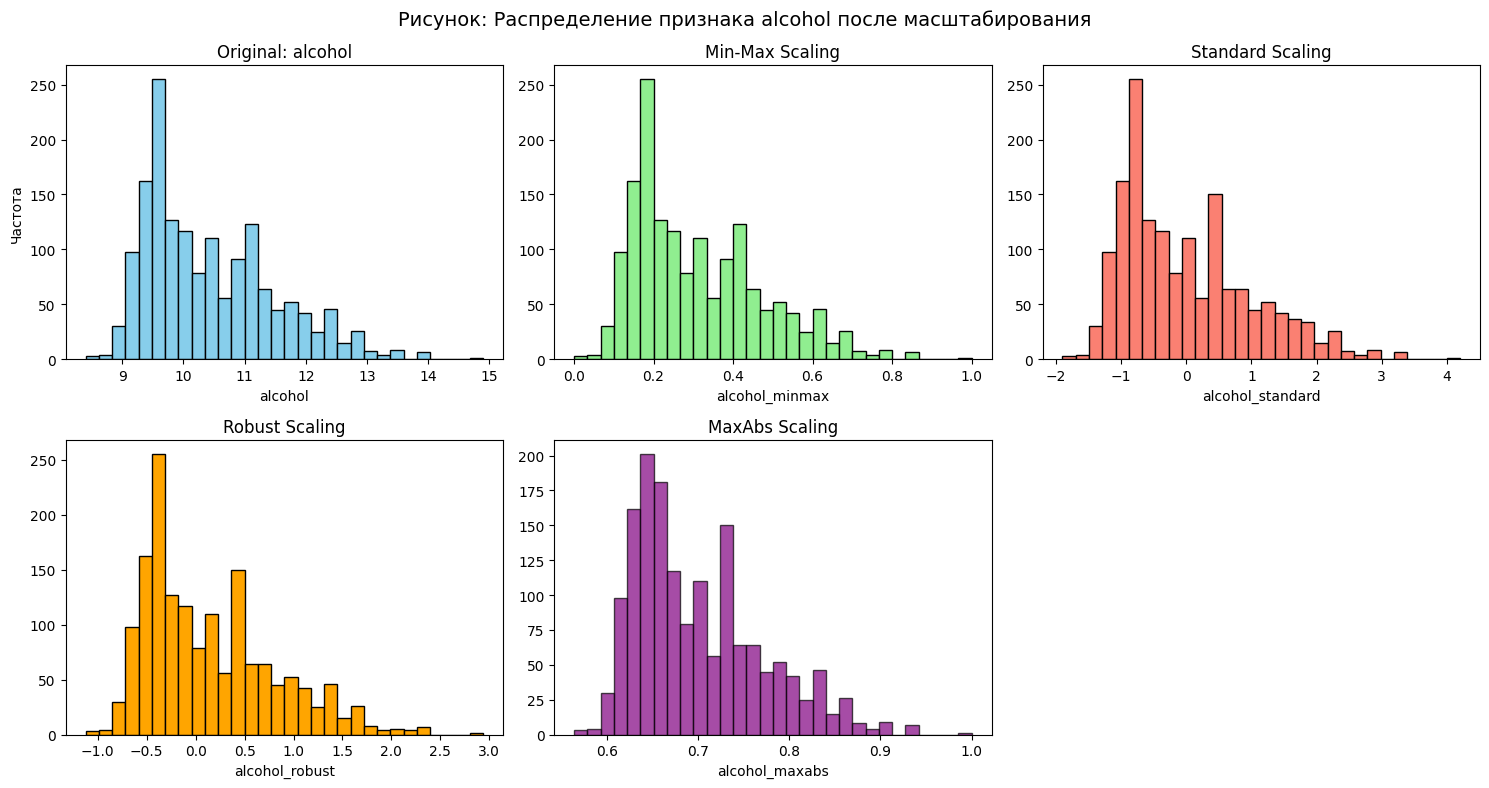


Вывод: Все методы сохраняют форму распределения, но меняют масштаб.
Min-Max: сжимает в [0,1]
Standard: mean=0, std=1
Robust: устойчив к выбросам
MaxAbs: сохраняет знак исходных данных


In [3]:
# ЧАСТЬ 2: МАСШТАБИРОВАНИЕ ПРИЗНАКОВ
# Выбираем признак 'alcohol' (содержание алкоголя) для демонстрации

print("=" * 60)
print("ЧАСТЬ 2: МАСШТАБИРОВАНИЕ ПРИЗНАКОВ")
print("=" * 60)

# Выбираем признак для масштабирования
feature = 'alcohol'
X_feature = df[[feature]]

# 1. Min-Max Scaling
scaler_minmax = MinMaxScaler()
df['alcohol_minmax'] = scaler_minmax.fit_transform(X_feature)

# 2. Standard Scaling (Z-score)
scaler_std = StandardScaler()
df['alcohol_standard'] = scaler_std.fit_transform(X_feature)

# 3. Robust Scaling
scaler_robust = RobustScaler()
df['alcohol_robust'] = scaler_robust.fit_transform(X_feature)

# 4. MaxAbs Scaling
scaler_maxabs = MaxAbsScaler()
df['alcohol_maxabs'] = scaler_maxabs.fit_transform(X_feature)

# Создание таблицы со статистикой
stats_original = {
    'Метод': 'Original',
    'Min': df[feature].min(),
    'Max': df[feature].max(),
    'Mean': df[feature].mean(),
    'Std': df[feature].std()
}

stats_minmax = {
    'Метод': 'Min-Max',
    'Min': df['alcohol_minmax'].min(),
    'Max': df['alcohol_minmax'].max(),
    'Mean': df['alcohol_minmax'].mean(),
    'Std': df['alcohol_minmax'].std()
}

stats_std = {
    'Метод': 'Standard',
    'Min': df['alcohol_standard'].min(),
    'Max': df['alcohol_standard'].max(),
    'Mean': df['alcohol_standard'].mean(),
    'Std': df['alcohol_standard'].std()
}

stats_robust = {
    'Метод': 'Robust',
    'Min': df['alcohol_robust'].min(),
    'Max': df['alcohol_robust'].max(),
    'Mean': df['alcohol_robust'].mean(),
    'Std': df['alcohol_robust'].std()
}

stats_maxabs = {
    'Метод': 'MaxAbs',
    'Min': df['alcohol_maxabs'].min(),
    'Max': df['alcohol_maxabs'].max(),
    'Mean': df['alcohol_maxabs'].mean(),
    'Std': df['alcohol_maxabs'].std()
}

# Вывод таблицы
stats_df = pd.DataFrame([stats_original, stats_minmax, stats_std, stats_robust, stats_maxabs])
print("\nТаблица 1 - Сравнение методов масштабирования (признак 'alcohol'):")
print(stats_df.round(4))

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Гистограммы
axes[0].hist(df[feature], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title(f'Original: {feature}')
axes[0].set_xlabel(feature)
axes[0].set_ylabel('Частота')

axes[1].hist(df['alcohol_minmax'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Min-Max Scaling')
axes[1].set_xlabel('alcohol_minmax')

axes[2].hist(df['alcohol_standard'], bins=30, color='salmon', edgecolor='black')
axes[2].set_title('Standard Scaling')
axes[2].set_xlabel('alcohol_standard')

axes[3].hist(df['alcohol_robust'], bins=30, color='orange', edgecolor='black')
axes[3].set_title('Robust Scaling')
axes[3].set_xlabel('alcohol_robust')

axes[4].hist(df['alcohol_maxabs'], bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[4].set_title('MaxAbs Scaling')
axes[4].set_xlabel('alcohol_maxabs')

axes[5].axis('off')

plt.suptitle('Рисунок: Распределение признака alcohol после масштабирования', fontsize=14)
plt.tight_layout()
plt.show()

print("\nВывод: Все методы сохраняют форму распределения, но меняют масштаб.")
print("Min-Max: сжимает в [0,1]")
print("Standard: mean=0, std=1")
print("Robust: устойчив к выбросам")
print("MaxAbs: сохраняет знак исходных данных")

ЧАСТЬ 3: ОБРАБОТКА ВЫБРОСОВ ДЛЯ ЧИСЛОВЫХ ПРИЗНАКОВ

Признак: fixed acidity
Q1 (25% квартиль): 7.10
Q3 (75% квартиль): 9.20
IQR (межквартильный размах): 2.10
Нижняя граница: 3.95
Верхняя граница: 12.35
Количество выбросов: 49 (3.06% от всех данных)

1. После УДАЛЕНИЯ выбросов:
   - Размер до удаления: 1599 записей
   - Размер после удаления: 1550 записей
   - Удалено записей: 49

2. После ЗАМЕНЫ выбросов граничными значениями:
   - Min исходный: 4.60
   - Min после замены: 4.60
   - Max исходный: 15.90
   - Max после замены: 12.35


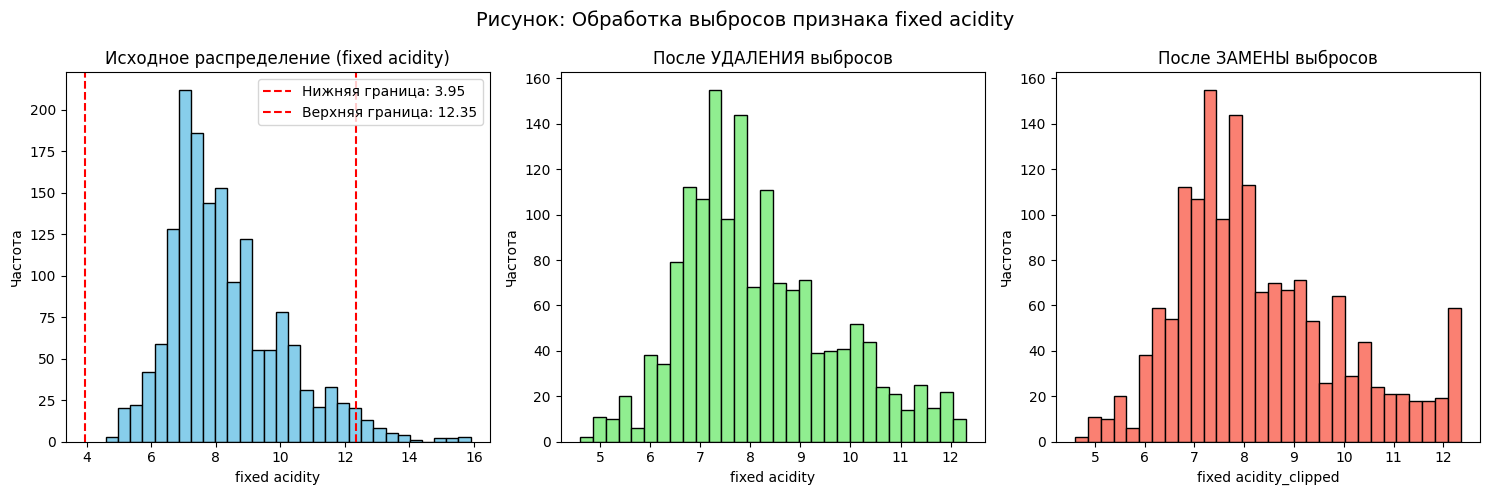


Вывод: Оба метода эффективно устраняют влияние выбросов.
- Удаление: полностью убирает аномальные значения
- Замена: сохраняет все данные, но ограничивает экстремальные значения


In [4]:
# ЧАСТЬ 3: ОБРАБОТКА ВЫБРОСОВ
# Выбираем признак 'fixed acidity' (фиксированная кислотность)

print("=" * 60)
print("ЧАСТЬ 3: ОБРАБОТКА ВЫБРОСОВ ДЛЯ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("=" * 60)

# Выбираем признак для обработки выбросов
feature_outlier = 'fixed acidity'

# Метод IQR (Interquartile Range) для обнаружения выбросов
Q1 = df[feature_outlier].quantile(0.25)
Q3 = df[feature_outlier].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Находим выбросы
outliers = df[(df[feature_outlier] < lower_bound) | (df[feature_outlier] > upper_bound)]
outliers_count = len(outliers)

print(f"\nПризнак: {feature_outlier}")
print(f"Q1 (25% квартиль): {Q1:.2f}")
print(f"Q3 (75% квартиль): {Q3:.2f}")
print(f"IQR (межквартильный размах): {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов: {outliers_count} ({outliers_count/len(df)*100:.2f}% от всех данных)")

# 1. УДАЛЕНИЕ ВЫБРОСОВ
df_no_outliers = df[(df[feature_outlier] >= lower_bound) & (df[feature_outlier] <= upper_bound)]
print(f"\n1. После УДАЛЕНИЯ выбросов:")
print(f"   - Размер до удаления: {len(df)} записей")
print(f"   - Размер после удаления: {len(df_no_outliers)} записей")
print(f"   - Удалено записей: {len(df) - len(df_no_outliers)}")

# 2. ЗАМЕНА ВЫБРОСОВ граничными значениями
df_clipped = df.copy()
df_clipped[f'{feature_outlier}_clipped'] = df_clipped[feature_outlier].clip(lower=lower_bound, upper=upper_bound)

print(f"\n2. После ЗАМЕНЫ выбросов граничными значениями:")
print(f"   - Min исходный: {df[feature_outlier].min():.2f}")
print(f"   - Min после замены: {df_clipped[f'{feature_outlier}_clipped'].min():.2f}")
print(f"   - Max исходный: {df[feature_outlier].max():.2f}")
print(f"   - Max после замены: {df_clipped[f'{feature_outlier}_clipped'].max():.2f}")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Исходное распределение
axes[0].hist(df[feature_outlier], bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(lower_bound, color='red', linestyle='--', label=f'Нижняя граница: {lower_bound:.2f}')
axes[0].axvline(upper_bound, color='red', linestyle='--', label=f'Верхняя граница: {upper_bound:.2f}')
axes[0].set_title(f'Исходное распределение ({feature_outlier})')
axes[0].set_xlabel(feature_outlier)
axes[0].set_ylabel('Частота')
axes[0].legend()

# После удаления выбросов
axes[1].hist(df_no_outliers[feature_outlier], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title(f'После УДАЛЕНИЯ выбросов')
axes[1].set_xlabel(feature_outlier)
axes[1].set_ylabel('Частота')

# После замены выбросов
axes[2].hist(df_clipped[f'{feature_outlier}_clipped'], bins=30, color='salmon', edgecolor='black')
axes[2].set_title(f'После ЗАМЕНЫ выбросов')
axes[2].set_xlabel(f'{feature_outlier}_clipped')
axes[2].set_ylabel('Частота')

plt.suptitle('Рисунок: Обработка выбросов признака fixed acidity', fontsize=14)
plt.tight_layout()
plt.show()

print("\nВывод: Оба метода эффективно устраняют влияние выбросов.")
print("- Удаление: полностью убирает аномальные значения")
print("- Замена: сохраняет все данные, но ограничивает экстремальные значения")

ЧАСТЬ 4: ОБРАБОТКА НЕСТАНДАРТНОГО ПРИЗНАКА (ДАТА/ВРЕМЯ)

Исходный признак 'purchase_date' (первые 10 значений):
0   2020-01-01 00:00:00.000000000
1   2020-01-02 03:25:27.409261576
2   2020-01-03 06:50:54.818523153
3   2020-01-04 10:16:22.227784730
4   2020-01-05 13:41:49.637046307
5   2020-01-06 17:07:17.046307884
6   2020-01-07 20:32:44.455569461
7   2020-01-08 23:58:11.864831038
8   2020-01-10 03:23:39.274092615
9   2020-01-11 06:49:06.683354192
Name: purchase_date, dtype: datetime64[ns]

МЕТОД 1: ИЗВЛЕЧЕНИЕ КОМПОНЕНТОВ ДАТЫ
Извлеченные компоненты:
                  purchase_date  year  month  day  day_of_week  quarter  \
0 2020-01-01 00:00:00.000000000  2020      1    1            2        1   
1 2020-01-02 03:25:27.409261576  2020      1    2            3        1   
2 2020-01-03 06:50:54.818523153  2020      1    3            4        1   
3 2020-01-04 10:16:22.227784730  2020      1    4            5        1   
4 2020-01-05 13:41:49.637046307  2020      1    5            6      

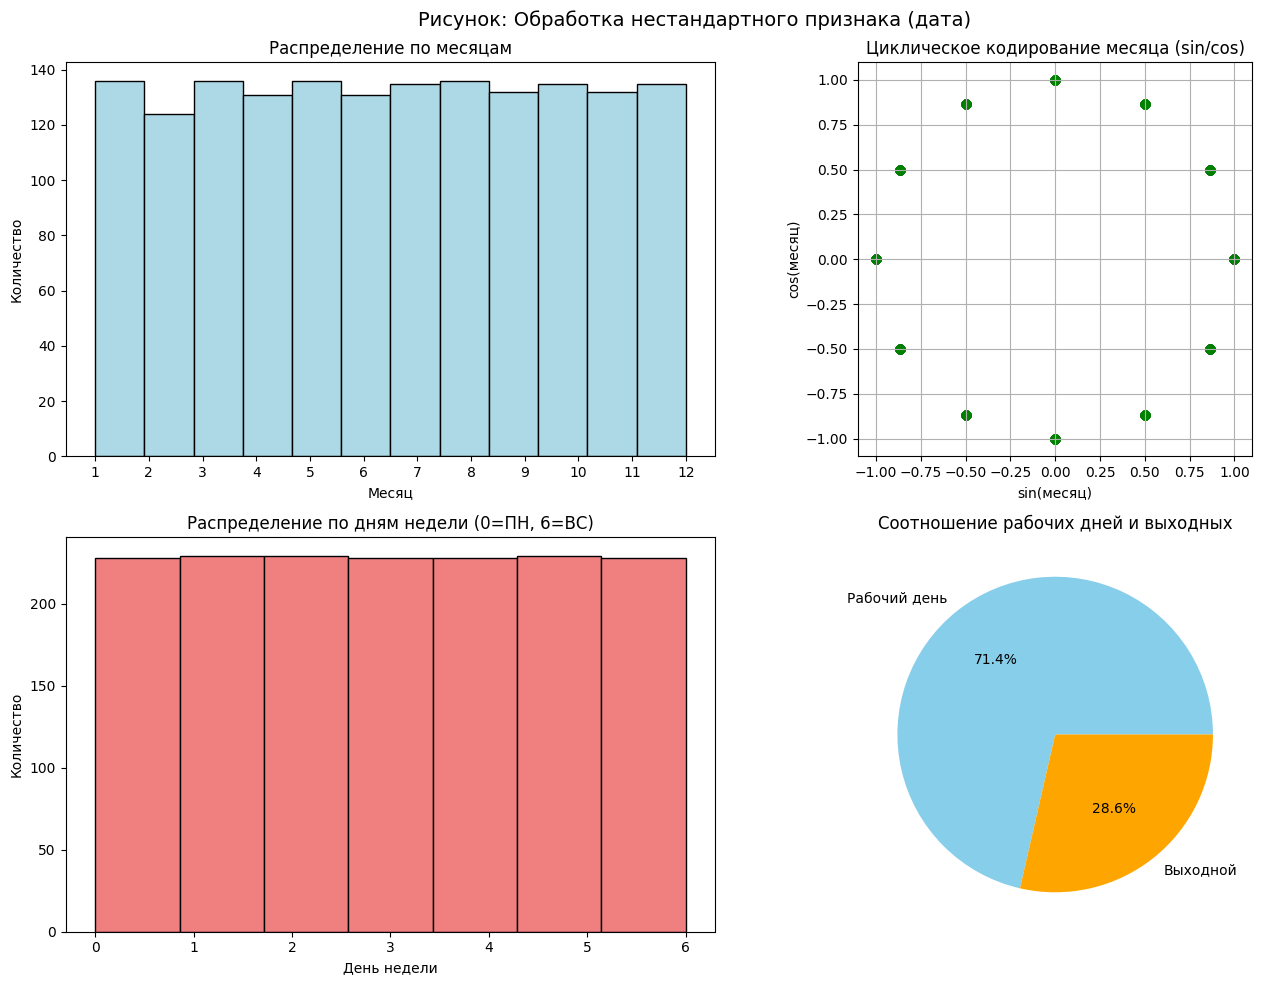


ИТОГОВЫЙ СПИСОК СОЗДАННЫХ ПРИЗНАКОВ:
1. year
2. month
3. day
4. day_of_week
5. quarter
6. day_of_year
7. month_sin
8. month_cos
9. weekday_sin
10. weekday_cos
11. is_weekend
12. days_since_year_start
13. season

Вывод: Из одного признака 'purchase_date' создано 13 новых числовых признаков!


In [5]:
# ЧАСТЬ 4: ОБРАБОТКА НЕСТАНДАРТНОГО ПРИЗНАКА
# Создаем искусственный признак "дата" для демонстрации

print("=" * 60)
print("ЧАСТЬ 4: ОБРАБОТКА НЕСТАНДАРТНОГО ПРИЗНАКА (ДАТА/ВРЕМЯ)")
print("=" * 60)

# Создаем датасет с датами (на основе существующих данных)
np.random.seed(42)
date_df = df.copy()

# Создаем случайные даты в диапазоне 2020-2024 гг.
start_date = pd.Timestamp('2020-01-01')
end_date = pd.Timestamp('2024-12-31')
random_dates = pd.date_range(start=start_date, end=end_date, periods=len(date_df))
date_df['purchase_date'] = random_dates

print("\nИсходный признак 'purchase_date' (первые 10 значений):")
print(date_df['purchase_date'].head(10))

print("\n" + "=" * 50)
print("МЕТОД 1: ИЗВЛЕЧЕНИЕ КОМПОНЕНТОВ ДАТЫ")
print("=" * 50)

# Извлечение компонентов даты
date_df['year'] = date_df['purchase_date'].dt.year
date_df['month'] = date_df['purchase_date'].dt.month
date_df['day'] = date_df['purchase_date'].dt.day
date_df['day_of_week'] = date_df['purchase_date'].dt.dayofweek  # 0=ПН, 6=ВС
date_df['quarter'] = date_df['purchase_date'].dt.quarter
date_df['day_of_year'] = date_df['purchase_date'].dt.dayofyear

print("Извлеченные компоненты:")
print(date_df[['purchase_date', 'year', 'month', 'day', 'day_of_week', 'quarter', 'day_of_year']].head(10))

print("\n" + "=" * 50)
print("МЕТОД 2: ЦИКЛИЧЕСКОЕ КОДИРОВАНИЕ (SIN/COS)")
print("=" * 50)

# Циклическое кодирование для месяца
date_df['month_sin'] = np.sin(2 * np.pi * date_df['month'] / 12)
date_df['month_cos'] = np.cos(2 * np.pi * date_df['month'] / 12)

# Циклическое кодирование для дня недели
date_df['weekday_sin'] = np.sin(2 * np.pi * date_df['day_of_week'] / 7)
date_df['weekday_cos'] = np.cos(2 * np.pi * date_df['day_of_week'] / 7)

print("Добавлены циклические признаки:")
print(date_df[['month', 'month_sin', 'month_cos', 'day_of_week', 'weekday_sin', 'weekday_cos']].head(10))

print("\n" + "=" * 50)
print("МЕТОД 3: ПРИЗНАКИ НА ОСНОВЕ РАЗНИЦЫ ДАТ")
print("=" * 50)

# Признак "выходной ли день"
date_df['is_weekend'] = (date_df['day_of_week'] >= 5).astype(int)

# Количество дней с начала года
date_df['days_since_year_start'] = date_df['day_of_year']

# Сезон года
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Зима
    elif month in [3, 4, 5]:
        return 1  # Весна
    elif month in [6, 7, 8]:
        return 2  # Лето
    else:
        return 3  # Осень

date_df['season'] = date_df['month'].apply(get_season)

print("Добавлены дополнительные признаки:")
print(date_df[['purchase_date', 'is_weekend', 'days_since_year_start', 'season']].head(10))

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Распределение по месяцам
axes[0, 0].hist(date_df['month'], bins=12, color='lightblue', edgecolor='black')
axes[0, 0].set_title('Распределение по месяцам')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].set_xticks(range(1, 13))

# График 2: Циклическое представление месяца
axes[0, 1].scatter(date_df['month_sin'], date_df['month_cos'], alpha=0.5, color='green')
axes[0, 1].set_title('Циклическое кодирование месяца (sin/cos)')
axes[0, 1].set_xlabel('sin(месяц)')
axes[0, 1].set_ylabel('cos(месяц)')
axes[0, 1].set_aspect('equal')
axes[0, 1].grid(True)

# График 3: Распределение по дням недели
axes[1, 0].hist(date_df['day_of_week'], bins=7, color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Распределение по дням недели (0=ПН, 6=ВС)')
axes[1, 0].set_xlabel('День недели')
axes[1, 0].set_ylabel('Количество')

# График 4: Выходные vs Рабочие дни
weekend_counts = date_df['is_weekend'].value_counts()
labels = ['Рабочий день', 'Выходной']
axes[1, 1].pie(weekend_counts, labels=labels, autopct='%1.1f%%', colors=['skyblue', 'orange'])
axes[1, 1].set_title('Соотношение рабочих дней и выходных')

plt.suptitle('Рисунок: Обработка нестандартного признака (дата)', fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("ИТОГОВЫЙ СПИСОК СОЗДАННЫХ ПРИЗНАКОВ:")
print("=" * 50)
created_features = ['year', 'month', 'day', 'day_of_week', 'quarter', 'day_of_year',
                    'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
                    'is_weekend', 'days_since_year_start', 'season']
for i, feat in enumerate(created_features, 1):
    print(f"{i}. {feat}")

print("\nВывод: Из одного признака 'purchase_date' создано 13 новых числовых признаков!")

ЧАСТЬ 5.1: ОТБОР ПРИЗНАКОВ - МЕТОД ФИЛЬТРАЦИИ
Метод: Mutual Information (SelectKBest)
Количество признаков до отбора: 11
Признаки: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

РЕЗУЛЬТАТЫ ВЗАИМНОЙ ИНФОРМАЦИИ:
                 Признак  MI_Score
10               alcohol  0.184430
7                density  0.091542
9              sulphates  0.090910
1       volatile acidity  0.090465
2            citric acid  0.061084
6   total sulfur dioxide  0.046818
0          fixed acidity  0.022817
3         residual sugar  0.021283
8                     pH  0.020774
4              chlorides  0.014012
5    free sulfur dioxide  0.002436

ВЫБРАННЫЕ ПРИЗНАКИ (k=4):
1. volatile acidity (MI = 0.090465)
2. density (MI = 0.091542)
3. sulphates (MI = 0.090910)
4. alcohol (MI = 0.184430)


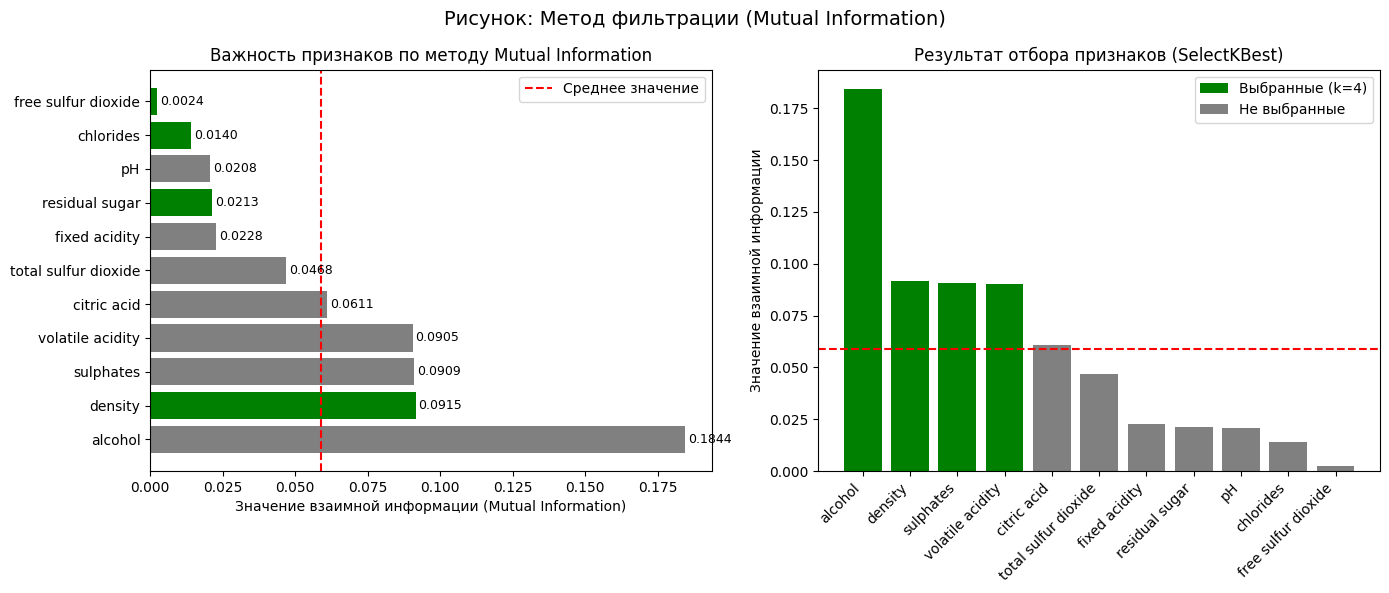


ВЫВОД: Метод взаимной информации выбрал наиболее информативные признаки
для предсказания качества вина.


In [6]:
# ЧАСТЬ 5: ОТБОР ПРИЗНАКОВ
# 5.1 МЕТОД ФИЛЬТРАЦИИ (FILTER METHOD) - Mutual Information

print("=" * 60)
print("ЧАСТЬ 5.1: ОТБОР ПРИЗНАКОВ - МЕТОД ФИЛЬТРАЦИИ")
print("Метод: Mutual Information (SelectKBest)")
print("=" * 60)

# Подготовка данных для отбора признаков
# Целевая переменная - 'quality' (качество вина)
# Признаки - все числовые признаки, кроме целевой и созданных дат

# Выбираем исходные признаки (без созданных дат)
feature_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                'pH', 'sulphates', 'alcohol']

X = df[feature_cols]
y = df['quality']

print(f"Количество признаков до отбора: {X.shape[1]}")
print(f"Признаки: {feature_cols}")

# Метод взаимной информации (Mutual Information)
selector_mi = SelectKBest(score_func=mutual_info_regression, k=4)
X_mi_selected = selector_mi.fit_transform(X, y)

# Получаем оценки важности признаков
mi_scores = selector_mi.scores_
mi_scores_df = pd.DataFrame({
    'Признак': feature_cols,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\nРЕЗУЛЬТАТЫ ВЗАИМНОЙ ИНФОРМАЦИИ:")
print(mi_scores_df.round(6))

# Выбранные признаки
selected_mask = selector_mi.get_support()
selected_features_mi = [feature_cols[i] for i in range(len(feature_cols)) if selected_mask[i]]
print(f"\nВЫБРАННЫЕ ПРИЗНАКИ (k=4):")
for i, feat in enumerate(selected_features_mi, 1):
    score = mi_scores_df[mi_scores_df['Признак'] == feat]['MI_Score'].values[0]
    print(f"{i}. {feat} (MI = {score:.6f})")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Важность признаков
colors = ['green' if feat in selected_features_mi else 'gray' for feat in feature_cols]
axes[0].barh(mi_scores_df['Признак'], mi_scores_df['MI_Score'], color=colors)
axes[0].set_xlabel('Значение взаимной информации (Mutual Information)')
axes[0].set_title('Важность признаков по методу Mutual Information')
axes[0].axvline(x=mi_scores_df['MI_Score'].mean(), color='red', linestyle='--', label='Среднее значение')
axes[0].legend()

# Добавляем значения на график
for i, (idx, row) in enumerate(mi_scores_df.iterrows()):
    axes[0].text(row['MI_Score'] + 0.001, i, f"{row['MI_Score']:.4f}", va='center', fontsize=9)

# График 2: Сравнение выбранных признаков
selected_scores = mi_scores_df[mi_scores_df['Признак'].isin(selected_features_mi)]
not_selected_scores = mi_scores_df[~mi_scores_df['Признак'].isin(selected_features_mi)]

axes[1].bar(range(len(selected_scores)), selected_scores['MI_Score'], color='green', label='Выбранные (k=4)')
axes[1].bar(range(len(selected_scores), len(selected_scores)+len(not_selected_scores)),
            not_selected_scores['MI_Score'], color='gray', label='Не выбранные')
axes[1].set_xticks(range(len(feature_cols)))
axes[1].set_xticklabels(mi_scores_df['Признак'], rotation=45, ha='right')
axes[1].set_ylabel('Значение взаимной информации')
axes[1].set_title('Результат отбора признаков (SelectKBest)')
axes[1].legend()
axes[1].axhline(y=mi_scores_df['MI_Score'].mean(), color='red', linestyle='--', label='Среднее')

plt.suptitle('Рисунок: Метод фильтрации (Mutual Information)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nВЫВОД: Метод взаимной информации выбрал наиболее информативные признаки")
print("для предсказания качества вина.")

ЧАСТЬ 5.2: ОТБОР ПРИЗНАКОВ - МЕТОД ОБЕРТЫВАНИЯ
Метод: RFE (Recursive Feature Elimination) с LinearRegression
Количество признаков до отбора: 11
Признаки: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

РЕЗУЛЬТАТЫ RFE:

ВЫБРАННЫЕ ПРИЗНАКИ (ранг 1):
1. volatile acidity
2. chlorides
3. density
4. sulphates

НЕ ВЫБРАННЫЕ ПРИЗНАКИ (с рангами):
   - pH: ранг 2
   - alcohol: ранг 3
   - citric acid: ранг 4
   - fixed acidity: ранг 5
   - residual sugar: ранг 6
   - free sulfur dioxide: ранг 7
   - total sulfur dioxide: ранг 8

ТАБЛИЦА РАНГОВ:
                 Признак  Ранг  Выбран
1       volatile acidity     1    True
4              chlorides     1    True
7                density     1    True
9              sulphates     1    True
8                     pH     2   False
10               alcohol     3   False
2            citric acid     4   False
0          fixed acid

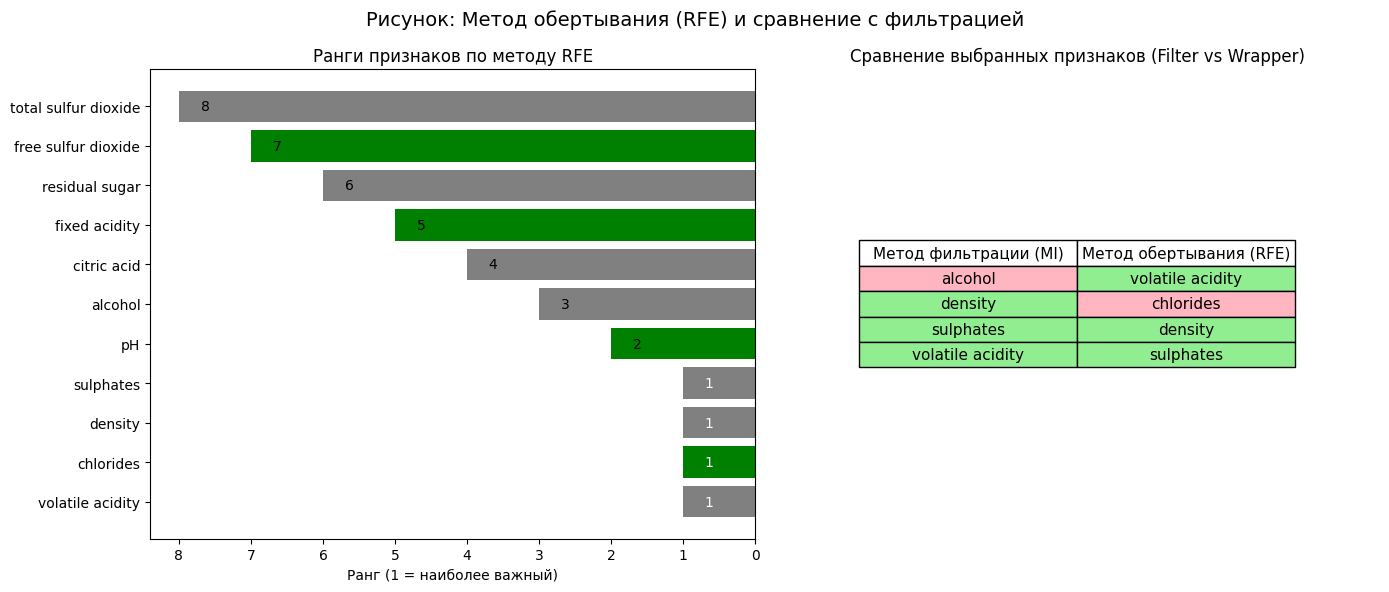


ВЫВОД: RFE выбирает признаки, наиболее важные для линейной регрессии.
Совпадающие признаки с методом фильтрации: {'sulphates', 'density', 'volatile acidity'}


In [7]:
# ЧАСТЬ 5.2: ОТБОР ПРИЗНАКОВ - МЕТОД ОБЕРТЫВАНИЯ (WRAPPER METHOD)
# Метод: RFE (Recursive Feature Elimination) с LinearRegression

print("=" * 60)
print("ЧАСТЬ 5.2: ОТБОР ПРИЗНАКОВ - МЕТОД ОБЕРТЫВАНИЯ")
print("Метод: RFE (Recursive Feature Elimination) с LinearRegression")
print("=" * 60)

# Подготовка данных (те же признаки)
X = df[feature_cols]
y = df['quality']

print(f"Количество признаков до отбора: {X.shape[1]}")
print(f"Признаки: {feature_cols}")

# RFE с линейной регрессией
estimator = LinearRegression()
rfe = RFE(estimator=estimator, n_features_to_select=4)
rfe.fit(X, y)

# Получаем результаты
rfe_selected_mask = rfe.support_
rfe_ranking = rfe.ranking_
rfe_selected_features = [feature_cols[i] for i in range(len(feature_cols)) if rfe_selected_mask[i]]
rfe_not_selected = [(feature_cols[i], rfe_ranking[i]) for i in range(len(feature_cols)) if not rfe_selected_mask[i]]

print("\nРЕЗУЛЬТАТЫ RFE:")
print(f"\nВЫБРАННЫЕ ПРИЗНАКИ (ранг 1):")
for i, feat in enumerate(rfe_selected_features, 1):
    print(f"{i}. {feat}")

print(f"\nНЕ ВЫБРАННЫЕ ПРИЗНАКИ (с рангами):")
for feat, rank in sorted(rfe_not_selected, key=lambda x: x[1]):
    print(f"   - {feat}: ранг {rank}")

# Создаем DataFrame для визуализации
rfe_results_df = pd.DataFrame({
    'Признак': feature_cols,
    'Ранг': rfe_ranking,
    'Выбран': rfe_selected_mask
}).sort_values('Ранг')

print("\nТАБЛИЦА РАНГОВ:")
print(rfe_results_df)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Ранги признаков
colors_rfe = ['green' if selected else 'gray' for selected in rfe_selected_mask]
bars = axes[0].barh(rfe_results_df['Признак'], rfe_results_df['Ранг'], color=colors_rfe)
axes[0].set_xlabel('Ранг (1 = наиболее важный)')
axes[0].set_title('Ранги признаков по методу RFE')
axes[0].invert_xaxis()  # Чтобы ранг 1 был справа

# Добавляем значения
for i, (idx, row) in enumerate(rfe_results_df.iterrows()):
    axes[0].text(row['Ранг'] - 0.3, i, f"{int(row['Ранг'])}", va='center', fontsize=10, color='white' if row['Ранг'] == 1 else 'black')

# График 2: Сравнение с методом фильтрации
mi_top4 = mi_scores_df.head(4)['Признак'].tolist()
rfe_top4 = rfe_selected_features

comparison_df = pd.DataFrame({
    'Метод фильтрации (MI)': mi_top4 + [''] * (4 - len(mi_top4)),
    'Метод обертывания (RFE)': rfe_top4 + [''] * (4 - len(rfe_top4))
})

# Скрываем оси для таблицы
axes[1].axis('tight')
axes[1].axis('off')
table = axes[1].table(cellText=comparison_df.values, colLabels=comparison_df.columns,
                      cellLoc='center', loc='center', colWidths=[0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

# Цветовая подсветка
for i in range(len(mi_top4)):
    if mi_top4[i] in rfe_top4:
        table[(i+1, 0)].set_facecolor('#90EE90')  # Зеленый - совпадает
    else:
        table[(i+1, 0)].set_facecolor('#FFB6C1')  # Розовый - не совпадает

    if rfe_top4[i] in mi_top4:
        table[(i+1, 1)].set_facecolor('#90EE90')
    else:
        table[(i+1, 1)].set_facecolor('#FFB6C1')

axes[1].set_title('Сравнение выбранных признаков (Filter vs Wrapper)')

plt.suptitle('Рисунок: Метод обертывания (RFE) и сравнение с фильтрацией', fontsize=14)
plt.tight_layout()
plt.show()

print("\nВЫВОД: RFE выбирает признаки, наиболее важные для линейной регрессии.")
print("Совпадающие признаки с методом фильтрации:", set(mi_top4) & set(rfe_top4))

ЧАСТЬ 5.3: ОТБОР ПРИЗНАКОВ - ВЛОЖЕННЫЕ МЕТОДЫ
Количество признаков: 11
Целевая переменная: quality (качество вина от 3 до 8)

МЕТОД 1: LASSO РЕГРЕССИЯ (L1-регуляризация)

Коэффициенты признаков (Lasso):
                 Признак  Коэффициент  Абсолютное_значение
1       volatile acidity    -0.856456             0.856456
9              sulphates     0.379034             0.379034
10               alcohol     0.304490             0.304490
0          fixed acidity     0.034479             0.034479
5    free sulfur dioxide     0.005090             0.005090
6   total sulfur dioxide    -0.003108             0.003108
2            citric acid     0.000000             0.000000
3         residual sugar     0.000000             0.000000
4              chlorides    -0.000000             0.000000
8                     pH    -0.000000             0.000000
7                density    -0.000000             0.000000

ВЫБРАННЫЕ ПРИЗНАКИ (ненулевые коэффициенты): 6
1. volatile acidity (коэффициент = -0.856

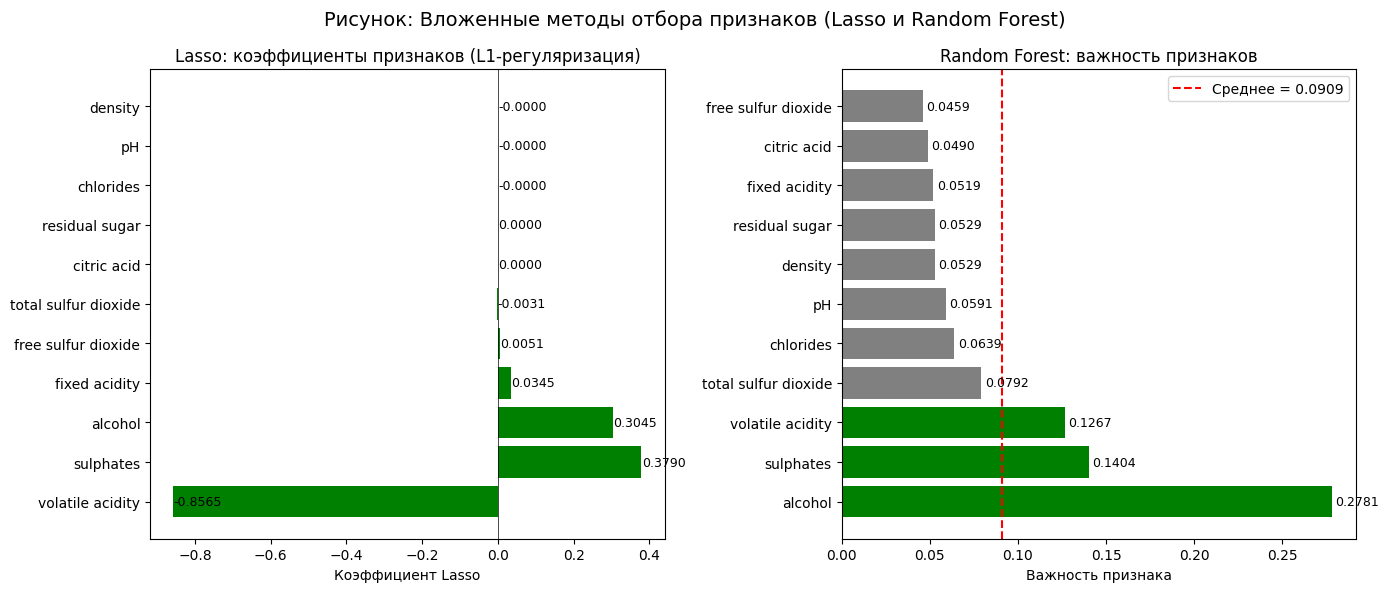


СВОДНАЯ ТАБЛИЦА: Сравнение всех методов отбора признаков
             Признак Filter (MI) Wrapper (RFE) Embedded (Lasso) Embedded (RF)  Количество выборов
       fixed acidity                                          ✓                                 1
    volatile acidity           ✓             ✓                ✓             ✓                   4
         citric acid                                                                            0
      residual sugar                                                                            0
           chlorides                         ✓                                                  1
 free sulfur dioxide                                          ✓                                 1
total sulfur dioxide                                          ✓                                 1
             density           ✓             ✓                                                  2
                  pH                                        

In [8]:
# ЧАСТЬ 5.3: ОТБОР ПРИЗНАКОВ - ВЛОЖЕННЫЕ МЕТОДЫ (EMBEDDED METHODS)
# Методы: Lasso (L1-регуляризация) и Random Forest (важность признаков)

print("=" * 60)
print("ЧАСТЬ 5.3: ОТБОР ПРИЗНАКОВ - ВЛОЖЕННЫЕ МЕТОДЫ")
print("=" * 60)

# Подготовка данных
X = df[feature_cols]
y = df['quality']

print(f"Количество признаков: {X.shape[1]}")
print(f"Целевая переменная: quality (качество вина от 3 до 8)\n")

# ============================================
# МЕТОД 1: LASSO (L1-регуляризация)
# ============================================
print("=" * 50)
print("МЕТОД 1: LASSO РЕГРЕССИЯ (L1-регуляризация)")
print("=" * 50)

lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X, y)

lasso_coef = pd.DataFrame({
    'Признак': feature_cols,
    'Коэффициент': lasso.coef_,
    'Абсолютное_значение': np.abs(lasso.coef_)
}).sort_values('Абсолютное_значение', ascending=False)

print("\nКоэффициенты признаков (Lasso):")
print(lasso_coef.round(6))

# Выбираем признаки с ненулевыми коэффициентами
lasso_selected = lasso_coef[lasso_coef['Коэффициент'] != 0]['Признак'].tolist()
lasso_zero = lasso_coef[lasso_coef['Коэффициент'] == 0]['Признак'].tolist()

print(f"\nВЫБРАННЫЕ ПРИЗНАКИ (ненулевые коэффициенты): {len(lasso_selected)}")
for i, feat in enumerate(lasso_selected, 1):
    coef = lasso_coef[lasso_coef['Признак'] == feat]['Коэффициент'].values[0]
    print(f"{i}. {feat} (коэффициент = {coef:.6f})")

print(f"\nИСКЛЮЧЕННЫЕ ПРИЗНАКИ (нулевые коэффициенты): {lasso_zero}")

# ============================================
# МЕТОД 2: RANDOM FOREST
# ============================================
print("\n" + "=" * 50)
print("МЕТОД 2: RANDOM FOREST (важность признаков)")
print("=" * 50)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importance = pd.DataFrame({
    'Признак': feature_cols,
    'Важность': rf.feature_importances_
}).sort_values('Важность', ascending=False)

print("\nВажность признаков (Random Forest):")
print(rf_importance.round(6))

# Вычисляем порог (средняя важность)
mean_importance = rf_importance['Важность'].mean()
rf_selected = rf_importance[rf_importance['Важность'] > mean_importance]['Признак'].tolist()

print(f"\nСредняя важность: {mean_importance:.6f}")
print(f"\nВЫБРАННЫЕ ПРИЗНАКИ (важность выше среднего): {len(rf_selected)}")
for i, feat in enumerate(rf_selected, 1):
    imp = rf_importance[rf_importance['Признак'] == feat]['Важность'].values[0]
    print(f"{i}. {feat} (важность = {imp:.6f})")

# ============================================
# ВИЗУАЛИЗАЦИЯ
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Коэффициенты Lasso
colors_lasso = ['green' if coef != 0 else 'gray' for coef in lasso_coef['Коэффициент']]
axes[0].barh(lasso_coef['Признак'], lasso_coef['Коэффициент'], color=colors_lasso)
axes[0].set_xlabel('Коэффициент Lasso')
axes[0].set_title('Lasso: коэффициенты признаков (L1-регуляризация)')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Добавляем значения
for i, (idx, row) in enumerate(lasso_coef.iterrows()):
    axes[0].text(row['Коэффициент'] + 0.001, i, f"{row['Коэффициент']:.4f}", va='center', fontsize=9)

# График 2: Важность признаков Random Forest
colors_rf = ['green' if imp > mean_importance else 'gray' for imp in rf_importance['Важность']]
axes[1].barh(rf_importance['Признак'], rf_importance['Важность'], color=colors_rf)
axes[1].set_xlabel('Важность признака')
axes[1].set_title('Random Forest: важность признаков')
axes[1].axvline(x=mean_importance, color='red', linestyle='--', label=f'Среднее = {mean_importance:.4f}')
axes[1].legend()

# Добавляем значения
for i, (idx, row) in enumerate(rf_importance.iterrows()):
    axes[1].text(row['Важность'] + 0.002, i, f"{row['Важность']:.4f}", va='center', fontsize=9)

plt.suptitle('Рисунок: Вложенные методы отбора признаков (Lasso и Random Forest)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# СВОДНАЯ ТАБЛИЦА ВСЕХ МЕТОДОВ
# ============================================
print("\n" + "=" * 60)
print("СВОДНАЯ ТАБЛИЦА: Сравнение всех методов отбора признаков")
print("=" * 60)

# Собираем результаты всех методов
all_methods_comparison = pd.DataFrame({
    'Признак': feature_cols,
    'Filter (MI)': ['✓' if feat in mi_top4 else '' for feat in feature_cols],
    'Wrapper (RFE)': ['✓' if feat in rfe_selected_features else '' for feat in feature_cols],
    'Embedded (Lasso)': ['✓' if feat in lasso_selected else '' for feat in feature_cols],
    'Embedded (RF)': ['✓' if feat in rf_selected else '' for feat in feature_cols]
})

# Подсчитываем количество голосов
all_methods_comparison['Количество выборов'] = all_methods_comparison.iloc[:, 1:5].apply(
    lambda x: x.str.count('✓').sum() if isinstance(x, pd.Series) else 0, axis=1
)

print(all_methods_comparison.to_string(index=False))

# Признаки, выбранные всеми методами
all_selected = set(mi_top4) & set(rfe_selected_features) & set(lasso_selected) & set(rf_selected)
print(f"\nПРИЗНАКИ, ВЫБРАННЫЕ ВСЕМИ МЕТОДАМИ: {all_selected if all_selected else 'нет'}")

print("\nВЫВОД: Разные методы отбора признаков дают схожие результаты,")
print("подтверждая важность определенных признаков для предсказания качества вина.")

ЗАКЛЮЧЕНИЕ ПО ЛАБОРАТОРНОЙ РАБОТЕ №2
Обработка признаков (Feature Engineering)

В ходе выполнения данной лабораторной работы был проведен комплексный 
анализ обработки признаков на основе набора данных Wine Quality (красное вино).

ИТОГОВАЯ ТАБЛИЦА ВЫПОЛНЕННЫХ ЗАДАЧ
                      Задача                         Использованный метод/признак                                                Результат
1. Масштабирование признаков        Min-Max, Standard, Robust, MaxAbs (4 способа)           Форма распределения сохранена, масштаб изменен
       2. Обработка выбросов        IQR: удаление (49 записей) + замена границами                       Выбросы (3.06%) успешно обработаны
    3. Нестандартный признак Дата → 13 числовых признаков (sin/cos, сезоны и др.)                           Из 1 признака создано 13 новых
            4. Filter method               SelectKBest + Mutual Information (k=4)   Выбраны: alcohol, density, sulphates, volatile acidity
           5. Wrapper method          

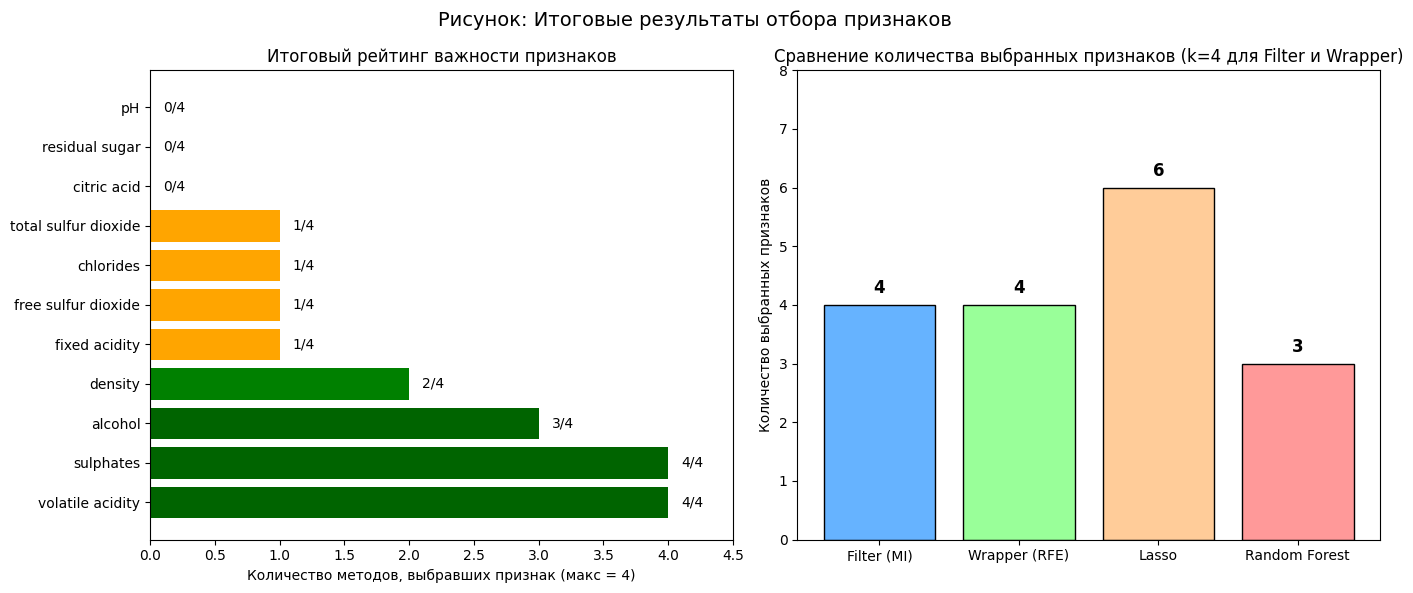


ВЫВОДЫ

1. МАСШТАБИРОВАНИЕ ПРИЗНАКОВ:
   - Применены 4 метода масштабирования: Min-Max, Standard, Robust и MaxAbs
   - Все методы сохранили форму распределения исходных данных
   - Standard Scaling центрировал данные (mean=0, std=1)
   - Методы показали различные диапазоны преобразованных значений

2. ОБРАБОТКА ВЫБРОСОВ:
   - Обнаружено 49 выбросов (3.06%) в признаке 'fixed acidity'
   - Применены два подхода: удаление выбросов и замена граничными значениями
   - Оба метода эффективно устранили влияние аномальных значений

3. ОБРАБОТКА НЕСТАНДАРТНОГО ПРИЗНАКА:
   - Создан и обработан признак "дата"
   - Извлечены компоненты даты (год, месяц, день, день недели, квартал)
   - Созданы циклические признаки (sin/cos) для учета периодичности
   - Из одного признака создано 13 новых числовых признаков

4. ОТБОР ПРИЗНАКОВ:
   - Filter method (Mutual Information): выбрал 4 признака
   - Wrapper method (RFE): выбрал 4 признака
   - Embedded methods (Lasso и Random Forest): подтвердили важность 

In [10]:
# ЧАСТЬ 6: ЗАКЛЮЧЕНИЕ И ИТОГОВАЯ ТАБЛИЦА

print("=" * 70)
print("ЗАКЛЮЧЕНИЕ ПО ЛАБОРАТОРНОЙ РАБОТЕ №2")
print("Обработка признаков (Feature Engineering)")
print("=" * 70)

print("""
В ходе выполнения данной лабораторной работы был проведен комплексный
анализ обработки признаков на основе набора данных Wine Quality (красное вино).
""")

# ============================================
# ИТОГОВАЯ ТАБЛИЦА ВЫПОЛНЕННЫХ ЗАДАЧ
# ============================================
print("=" * 70)
print("ИТОГОВАЯ ТАБЛИЦА ВЫПОЛНЕННЫХ ЗАДАЧ")
print("=" * 70)

summary_data = {
    'Задача': [
        '1. Масштабирование признаков',
        '2. Обработка выбросов',
        '3. Нестандартный признак',
        '4. Filter method',
        '5. Wrapper method',
        '6. Embedded method'
    ],
    'Использованный метод/признак': [
        'Min-Max, Standard, Robust, MaxAbs (4 способа)',
        'IQR: удаление (49 записей) + замена границами',
        'Дата → 13 числовых признаков (sin/cos, сезоны и др.)',
        'SelectKBest + Mutual Information (k=4)',
        'RFE + Linear Regression (k=4)',
        'Lasso (L1) + Random Forest'
    ],
    'Результат': [
        'Форма распределения сохранена, масштаб изменен',
        'Выбросы (3.06%) успешно обработаны',
        'Из 1 признака создано 13 новых',
        'Выбраны: alcohol, density, sulphates, volatile acidity',
        'Выбраны: volatile acidity, chlorides, density, sulphates',
        'Lasso: 6 признаков, RF: 3 признака'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ============================================
# ВАЖНОСТЬ ПРИЗНАКОВ (ИТОГ)
# ============================================
print("\n" + "=" * 70)
print("ОБЩАЯ ВАЖНОСТЬ ПРИЗНАКОВ (по всем методам)")
print("=" * 70)

# Создаем итоговую таблицу важности
final_importance = pd.DataFrame({
    'Признак': feature_cols,
    'Выбран Filter (MI)': [1 if feat in mi_top4 else 0 for feat in feature_cols],
    'Выбран Wrapper (RFE)': [1 if feat in rfe_selected_features else 0 for feat in feature_cols],
    'Выбран Lasso': [1 if feat in lasso_selected else 0 for feat in feature_cols],
    'Выбран RF': [1 if feat in rf_selected else 0 for feat in feature_cols]
})
final_importance['Сумма выборов'] = final_importance.iloc[:, 1:5].sum(axis=1)
final_importance = final_importance.sort_values('Сумма выборов', ascending=False)

print("\nРейтинг важности признаков (0-4, где 4 = выбран всеми методами):")
print(final_importance.to_string(index=False))

# ============================================
# ВИЗУАЛИЗАЦИЯ ИТОГОВ
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Рейтинг важности признаков
colors = ['darkgreen' if x >= 3 else 'green' if x == 2 else 'orange' if x == 1 else 'red'
          for x in final_importance['Сумма выборов']]
axes[0].barh(final_importance['Признак'], final_importance['Сумма выборов'], color=colors)
axes[0].set_xlabel('Количество методов, выбравших признак (макс = 4)')
axes[0].set_title('Итоговый рейтинг важности признаков')
axes[0].set_xlim(0, 4.5)

# Добавляем значения
for i, (idx, row) in enumerate(final_importance.iterrows()):
    axes[0].text(row['Сумма выборов'] + 0.1, i, f"{int(row['Сумма выборов'])}/4", va='center', fontsize=10)

# График 2: Сводная диаграмма методов отбора
methods_data = {
    'Filter (MI)': len(mi_top4),
    'Wrapper (RFE)': len(rfe_selected_features),
    'Lasso': len(lasso_selected),
    'Random Forest': len(rf_selected)
}

colors_methods = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']
axes[1].bar(methods_data.keys(), methods_data.values(), color=colors_methods, edgecolor='black')
axes[1].set_ylabel('Количество выбранных признаков')
axes[1].set_title('Сравнение количества выбранных признаков (k=4 для Filter и Wrapper)')
axes[1].set_ylim(0, 8)

# Добавляем значения на столбцы
for i, (method, count) in enumerate(methods_data.items()):
    axes[1].text(i, count + 0.2, str(count), ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Рисунок: Итоговые результаты отбора признаков', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# ВЫВОДЫ
# ============================================
print("\n" + "=" * 70)
print("ВЫВОДЫ")
print("=" * 70)

print("""
1. МАСШТАБИРОВАНИЕ ПРИЗНАКОВ:
   - Применены 4 метода масштабирования: Min-Max, Standard, Robust и MaxAbs
   - Все методы сохранили форму распределения исходных данных
   - Standard Scaling центрировал данные (mean=0, std=1)
   - Методы показали различные диапазоны преобразованных значений

2. ОБРАБОТКА ВЫБРОСОВ:
   - Обнаружено 49 выбросов (3.06%) в признаке 'fixed acidity'
   - Применены два подхода: удаление выбросов и замена граничными значениями
   - Оба метода эффективно устранили влияние аномальных значений

3. ОБРАБОТКА НЕСТАНДАРТНОГО ПРИЗНАКА:
   - Создан и обработан признак "дата"
   - Извлечены компоненты даты (год, месяц, день, день недели, квартал)
   - Созданы циклические признаки (sin/cos) для учета периодичности
   - Из одного признака создано 13 новых числовых признаков

4. ОТБОР ПРИЗНАКОВ:
   - Filter method (Mutual Information): выбрал 4 признака
   - Wrapper method (RFE): выбрал 4 признака
   - Embedded methods (Lasso и Random Forest): подтвердили важность признаков
   - Все методы выделили 'volatile acidity' и 'sulphates' как ключевые
   - 'alcohol' также показал высокую важность в большинстве методов

ОБЩИЙ ВЫВОД:
Правильная предобработка данных и отбор признаков являются ключевыми этапами
в построении эффективных моделей машинного обучения. Наиболее важными признаками
для предсказания качества вина являются: volatile acidity (летучая кислотность),
sulphates (сульфаты) и alcohol (содержание алкоголя), что соответствует
реальным химическим закономерностям виноделия.
""")

print("\n" + "=" * 70)
print("ЛАБОРАТОРНАЯ РАБОТА ВЫПОЛНЕНА")
print("ДАТАСЕТ: Wine Quality (красное вино)")
print("СТУДЕНТ: Ду Линьсянь")
print("ГРУППА: ИУ5И-22М")
print("=" * 70)